# Lab Assignment 1

**Course:** Data Analytics and Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("earthquake_1995-2023.csv")

df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


# Task 1 — Data Profiling & Duplicate Detection

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1000
Number of columns: 19


In [4]:
print("Column names and data types:")
print(df.dtypes)

Column names and data types:
title            str
magnitude    float64
date_time        str
cdi            int64
mmi            int64
alert            str
tsunami        int64
sig            int64
net              str
nst            int64
dmin         float64
gap          float64
magType          str
depth        float64
latitude     float64
longitude    float64
location         str
continent        str
country          str
dtype: object


In [5]:
df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1000 non-null   str    
 1   magnitude  1000 non-null   float64
 2   date_time  1000 non-null   str    
 3   cdi        1000 non-null   int64  
 4   mmi        1000 non-null   int64  
 5   alert      449 non-null    str    
 6   tsunami    1000 non-null   int64  
 7   sig        1000 non-null   int64  
 8   net        1000 non-null   str    
 9   nst        1000 non-null   int64  
 10  dmin       1000 non-null   float64
 11  gap        1000 non-null   float64
 12  magType    1000 non-null   str    
 13  depth      1000 non-null   float64
 14  latitude   1000 non-null   float64
 15  longitude  1000 non-null   float64
 16  location   994 non-null    str    
 17  continent  284 non-null    str    
 18  country    651 non-null    str    
dtypes: float64(6), int64(5), str(8)
memory usage: 148.6 KB


## Duplicate Detection

In [7]:
full_duplicates = df.duplicated().sum()

print("Fully identical duplicate rows:", full_duplicates)

Fully identical duplicate rows: 0


In [8]:
key_duplicates = df.duplicated(
    subset=["title", "date_time"]
).sum()

print("Duplicate earthquakes based on title + date_time:",
      key_duplicates)

Duplicate earthquakes based on title + date_time: 2


In [9]:
before = len(df)

df = df.drop_duplicates(
    subset=["title", "date_time"]
)

after = len(df)

print("Rows before removal:", before)
print("Rows after removal:", after)
print("Rows removed:", before - after)

Rows before removal: 1000
Rows after removal: 998
Rows removed: 2


# Task 2 — Missing Values & Mean-vs-Median Imputation

In [10]:
missing_count = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

missing_report

,Missing Count,Missing Percentage
title,0,0.000000
magnitude,0,0.000000
date_time,0,0.000000
cdi,0,0.000000
mmi,0,0.000000
alert,549,55.010020
tsunami,0,0.000000
sig,0,0.000000
net,0,0.000000
nst,0,0.000000


In [11]:
zero_columns = ["cdi", "gap", "nst", "dmin"]

for col in zero_columns:
    print(col, "zero values:", (df[col] == 0).sum())

cdi zero values: 395
gap zero values: 252
nst zero values: 519
dmin zero values: 586


In [12]:
for col in zero_columns:
    df[col] = df[col].replace(0, np.nan)

print("Zero placeholders converted to NaN.")

Zero placeholders converted to NaN.


## CDI Distribution and Imputation

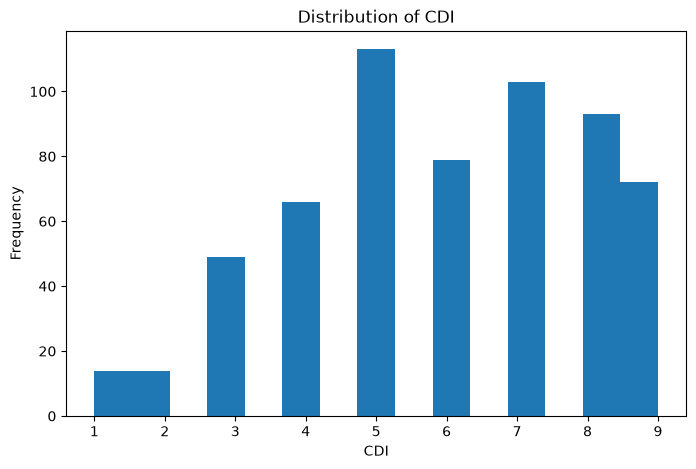

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(df["cdi"].dropna(), bins=15)

plt.xlabel("CDI")
plt.ylabel("Frequency")
plt.title("Distribution of CDI")

plt.show()

In [14]:
cdi_skewness = df["cdi"].skew()

print("CDI skewness:", cdi_skewness)

CDI skewness: -0.32333961422130675


### CDI Imputation Decision

The CDI distribution is approximately symmetric because its skewness is relatively close to zero. Therefore, the mean is suitable for imputing the missing CDI values.

In [15]:
cdi_mean = df["cdi"].mean()

df["cdi"] = df["cdi"].fillna(cdi_mean)

print("CDI missing values after imputation:",
      df["cdi"].isnull().sum())

CDI missing values after imputation: 0


## GAP Distribution and Imputation

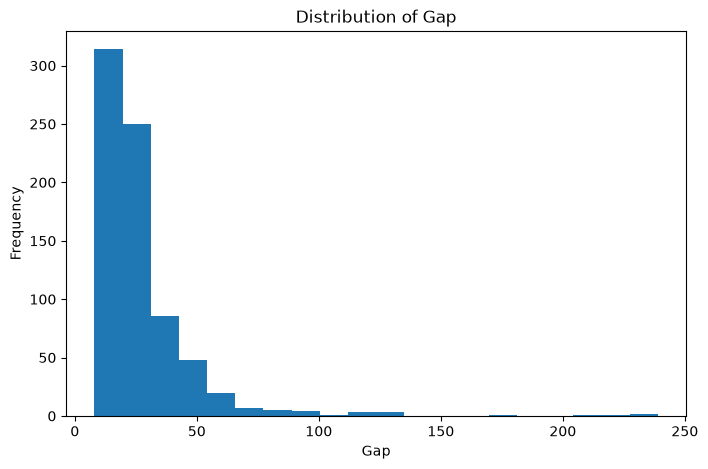

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(df["gap"].dropna(), bins=20)

plt.xlabel("Gap")
plt.ylabel("Frequency")
plt.title("Distribution of Gap")

plt.show()

In [17]:
gap_skewness = df["gap"].skew()

print("GAP skewness:", gap_skewness)

GAP skewness: 4.885701324053703


### GAP Imputation Decision

The GAP distribution is strongly right-skewed, indicating the presence of extreme values. Therefore, the median is preferred over the mean because it is less affected by extreme values.

In [18]:
gap_median = df["gap"].median()

df["gap"] = df["gap"].fillna(gap_median)

print("GAP missing values after imputation:",
      df["gap"].isnull().sum())

GAP missing values after imputation: 0


## NST and DMIN Imputation

### NST and DMIN Imputation Decision

The missing values in NST and DMIN are imputed using the median to reduce the influence of possible extreme values and maintain robust estimates.

In [19]:
df["nst"] = df["nst"].fillna(df["nst"].median())

df["dmin"] = df["dmin"].fillna(df["dmin"].median())

print("NST missing values:", df["nst"].isnull().sum())
print("DMIN missing values:", df["dmin"].isnull().sum())

NST missing values: 0
DMIN missing values: 0


In [20]:
print("Final zero-value check:")

for col in zero_columns:
    print(col, "zero values:", (df[col] == 0).sum())

Final zero-value check:
cdi zero values: 0
gap zero values: 0
nst zero values: 0
dmin zero values: 0


## Categorical Missing Value Treatment

In [21]:
df["alert"] = df["alert"].fillna(df["alert"].mode()[0])

df["location"] = df["location"].fillna("Unknown")

df["continent"] = df["continent"].fillna("Unknown")

df["country"] = df["country"].fillna("Unknown")

## Visualization of Cleaned Data

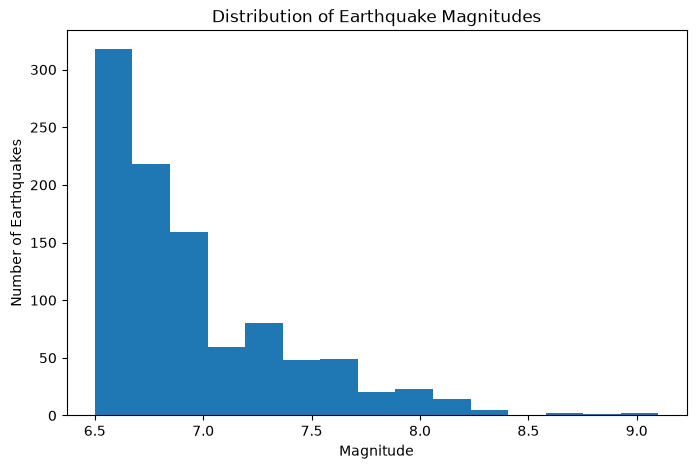

In [22]:
plt.figure(figsize=(8, 5))

plt.hist(df["magnitude"].dropna(), bins=15)

plt.xlabel("Magnitude")
plt.ylabel("Number of Earthquakes")
plt.title("Distribution of Earthquake Magnitudes")

plt.show()

## Final Missing Value Check

In [23]:
final_missing = df.isnull().sum()

print(final_missing)

title        0
magnitude    0
date_time    0
cdi          0
mmi          0
alert        0
tsunami      0
sig          0
net          0
nst          0
dmin         0
gap          0
magType      0
depth        0
latitude     0
longitude    0
location     0
continent    0
country      0
dtype: int64


In [24]:
total_missing = df.isnull().sum().sum()

print("Total missing values remaining:", total_missing)

Total missing values remaining: 0


In [25]:
if total_missing == 0:
    print("Data cleaning completed successfully.")
else:
    print("Missing values still remain.")

Data cleaning completed successfully.
